# Statistical Analysis of Swedish Auto Insurance Data

**DAT603 Project Assignment**

---

This notebook analyses the Swedish Auto Insurance dataset. The data contains 63 observations from geographical zones in Sweden, where X is the number of claims and Y is the total payment in thousands of Swedish Kronor (SEK).

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

## Load Data

In [2]:
df = pd.read_csv('Swedish_Auto_Insurance_Data.csv')
X = df['X']
Y = df['Y']

print(f'Dataset: {df.shape[0]} observations, {df.shape[1]} variables')
print()
df.head(10)

Dataset: 63 observations, 2 variables



,X,Y
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4
5,57,170.9
6,23,56.9
7,14,77.5
8,45,214.0
9,10,65.3


## Descriptive Statistics

In [3]:
desc = df.describe()
desc.loc['skewness'] = [X.skew(), Y.skew()]
desc.loc['kurtosis'] = [X.kurtosis(), Y.kurtosis()]
desc.loc['IQR'] = [X.quantile(0.75) - X.quantile(0.25), Y.quantile(0.75) - Y.quantile(0.25)]
print(desc.to_string())

                   X           Y
count      63.000000   63.000000
mean       22.904762   98.187302
std        23.351946   87.327553
min         0.000000    0.000000
25%         7.500000   38.850000
50%        14.000000   73.400000
75%        29.000000  140.000000
max       124.000000  422.200000
skewness    2.316240    1.627071
kurtosis    6.854108    3.334327
IQR        21.500000  101.150000


---

## 1. Exploratory Data Analysis

### 1(a) Histograms

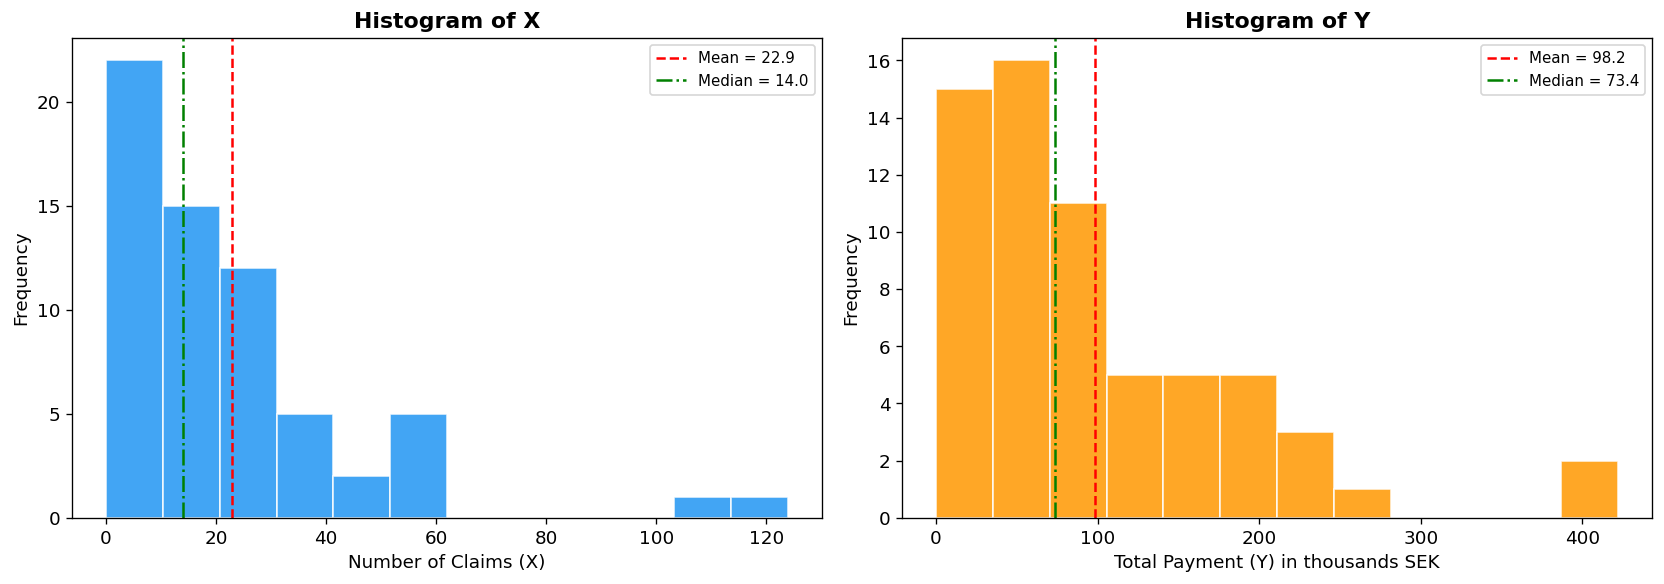

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for X
axes[0].hist(X, bins=12, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(X.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {X.mean():.1f}')
axes[0].axvline(X.median(), color='green', linestyle='-.', linewidth=1.5, label=f'Median = {X.median():.1f}')
axes[0].set_title('Histogram of X', fontweight='bold')
axes[0].set_xlabel('Number of Claims (X)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Histogram for Y
axes[1].hist(Y, bins=12, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].axvline(Y.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {Y.mean():.1f}')
axes[1].axvline(Y.median(), color='green', linestyle='-.', linewidth=1.5, label=f'Median = {Y.median():.1f}')
axes[1].set_title('Histogram of Y', fontweight='bold')
axes[1].set_xlabel('Total Payment (Y) in thousands SEK')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Comment on the shape of the distributions:**

- **X** is positively skewed (skewness = 2.32). Most zones have a low number of claims (0 to 30), with a few zones having much higher counts. The mean (22.9) is much larger than the median (14.0), which confirms the positive skew.

- **Y** is also positively skewed (skewness = 1.63). Most zones have total payments below 150 thousand SEK, but a few zones have payments above 300 thousand SEK. The mean (98.2) is higher than the median (73.4), confirming the rightward skew.

Both variables are right-skewed, which is common in insurance data.

### 1(b) Scatter Plot

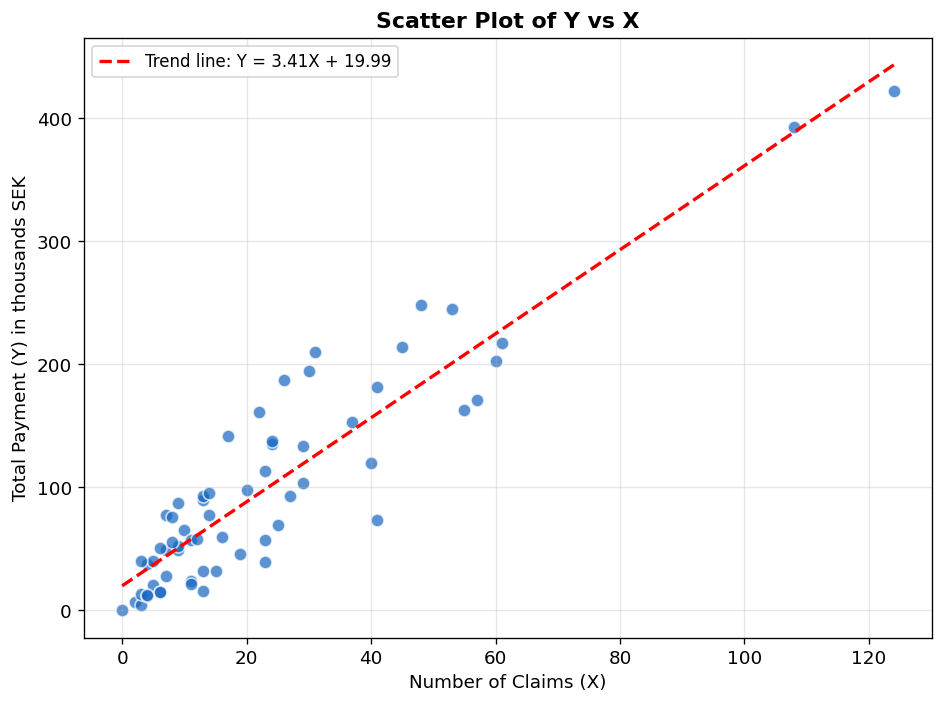

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X, Y, color='#1565C0', alpha=0.7, edgecolors='white', s=60)

# Add trend line
z = np.polyfit(X, Y, 1)
x_line = np.linspace(X.min(), X.max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2, linestyle='--',
        label=f'Trend line: Y = {z[0]:.2f}X + {z[1]:.2f}')

ax.set_title('Scatter Plot of Y vs X', fontweight='bold')
ax.set_xlabel('Number of Claims (X)')
ax.set_ylabel('Total Payment (Y) in thousands SEK')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Pattern observed:**

The scatter plot shows a clear positive linear relationship between X and Y. As the number of claims goes up, the total payment also goes up. The data points group closely around the trend line Y = 3.41X + 19.99. The relationship is linear rather than curved, which supports the use of simple linear regression.

### 1(c) Boxplots

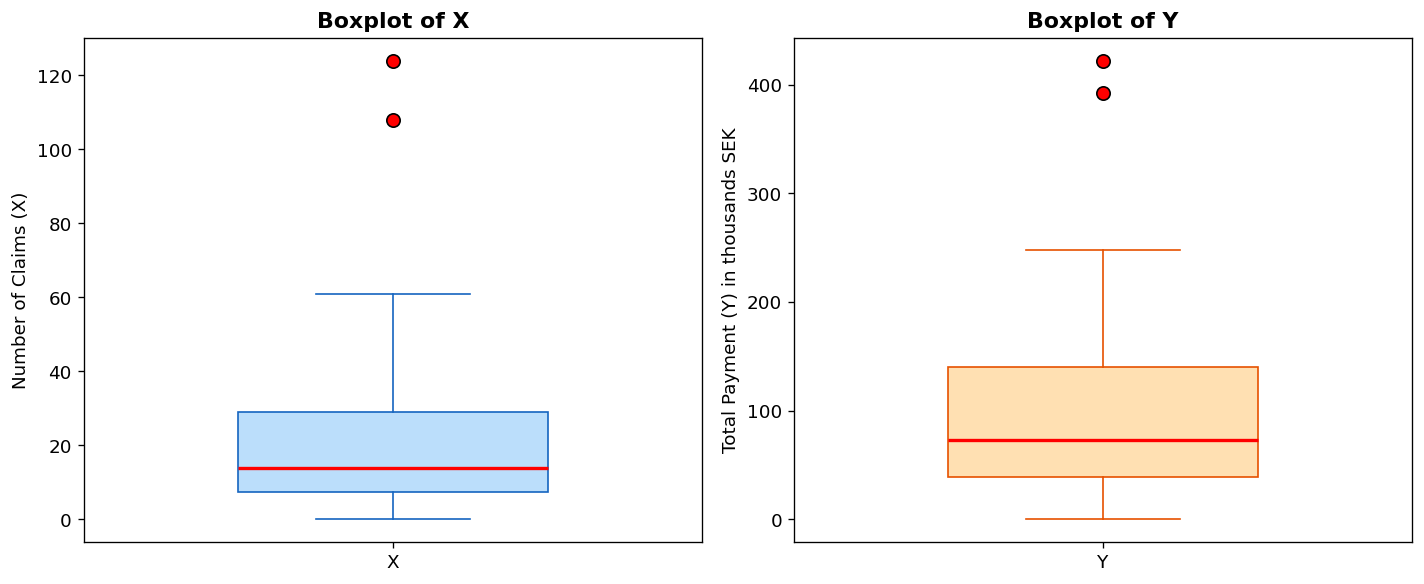

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for X
axes[0].boxplot(X, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='#BBDEFB', edgecolor='#1565C0'),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[0].set_title('Boxplot of X', fontweight='bold')
axes[0].set_ylabel('Number of Claims (X)')
axes[0].set_xticklabels(['X'])

# Boxplot for Y
axes[1].boxplot(Y, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='#FFE0B2', edgecolor='#E65100'),
                whiskerprops=dict(color='#E65100'),
                capprops=dict(color='#E65100'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[1].set_title('Boxplot of Y', fontweight='bold')
axes[1].set_ylabel('Total Payment (Y) in thousands SEK')
axes[1].set_xticklabels(['Y'])

plt.tight_layout()
plt.show()

In [7]:
# Outlier detection using IQR method
for var_name, var in [('X', X), ('Y', Y)]:
    Q1 = var.quantile(0.25)
    Q3 = var.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = var[(var < lower_fence) | (var > upper_fence)]
    
    print(f'{var_name}:')
    print(f'  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
    print(f'  Lower fence = {lower_fence:.2f}, Upper fence = {upper_fence:.2f}')
    if len(outliers) > 0:
        print(f'  Outliers found: {len(outliers)} values -> {outliers.values}')
    else:
        print(f'  No outliers found.')
    print()

X:
  Q1 = 7.50, Q3 = 29.00, IQR = 21.50
  Lower fence = -24.75, Upper fence = 61.25
  Outliers found: 2 values -> [108 124]

Y:
  Q1 = 38.85, Q3 = 140.00, IQR = 101.15
  Lower fence = -112.88, Upper fence = 291.73
  Outliers found: 2 values -> [392.5 422.2]



**Outlier analysis:**

- **X** has 2 outliers: X = 108 and X = 124. These are zones with very high claim counts.
- **Y** has 2 outliers: Y = 392.5 and Y = 422.2. These are zones with very high total payments.

The outliers in X and Y come from the same two geographical zones. Since the high Y values match the high X values and follow the linear trend, these are real extreme values and not data errors.

### 1(d) Correlation Coefficients

In [8]:
# Pearson's product-moment correlation
pearson_r, pearson_p = stats.pearsonr(X, Y)
print(f"Pearson's r = {pearson_r:.6f}, p-value = {pearson_p:.2e}")

# Spearman's rank correlation
spearman_rho, spearman_p = stats.spearmanr(X, Y)
print(f"Spearman's rho = {spearman_rho:.6f}, p-value = {spearman_p:.2e}")

# Kendall's tau correlation
kendall_tau, kendall_p = stats.kendalltau(X, Y)
print(f"Kendall's tau = {kendall_tau:.6f}, p-value = {kendall_p:.2e}")

Pearson's r = 0.912878, p-value = 2.05e-25
Spearman's rho = 0.864895, p-value = 6.44e-20
Kendall's tau = 0.701987, p-value = 7.25e-16


**Comment on correlation:**

| Method | Coefficient | Value | p-value | Significant? |
|--------|-------------|-------|---------|--------------|
| Pearson | r | 0.9129 | 2.05e-25 | Yes |
| Spearman | rho | 0.8649 | 6.44e-20 | Yes |
| Kendall | tau | 0.7020 | 7.25e-16 | Yes |

All three methods show a strong positive relationship between X and Y. All p-values are far below 0.05, so the correlations are statistically significant. The agreement across parametric (Pearson) and non-parametric (Spearman, Kendall) methods makes this finding reliable.

---

## 2. Linear Regression: Y on X

In [9]:
# Fit OLS regression
X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     305.0
Date:                Wed, 06 May 2026   Prob (F-statistic):           2.05e-25
Time:                        01:41:38   Log-Likelihood:                -314.04
No. Observations:                  63   AIC:                             632.1
Df Residuals:                      61   BIC:                             636.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9945      6.368      3.140      0.0

In [10]:
# Extract key values
b0 = model.params['const']
b1 = model.params['X']

print('Regression Equation:')
print(f'  Y_hat = {b0:.4f} + {b1:.4f} * X')
print()
print(f'Intercept (b0) = {b0:.4f}')
print(f'  t = {model.tvalues["const"]:.4f}, p = {model.pvalues["const"]:.6f}')
print(f'  Significant at 0.05: {"Yes" if model.pvalues["const"] < 0.05 else "No"}')
print()
print(f'Slope (b1) = {b1:.4f}')
print(f'  t = {model.tvalues["X"]:.4f}, p = {model.pvalues["X"]:.2e}')
print(f'  Significant at 0.05: {"Yes" if model.pvalues["X"] < 0.05 else "No"}')
print(f'  For each extra claim, total payment goes up by about {b1:.2f} thousand SEK.')
print()
print('Goodness-of-Fit:')
print(f'  R-squared = {model.rsquared:.6f} ({model.rsquared*100:.2f}% of variation in Y explained by X)')
print(f'  Adjusted R-squared = {model.rsquared_adj:.6f}')
print(f'  F-statistic = {model.fvalue:.4f}, p = {model.f_pvalue:.2e}')
print(f'  Model significant: {"Yes" if model.f_pvalue < 0.05 else "No"}')

Regression Equation:
  Y_hat = 19.9945 + 3.4138 * X

Intercept (b0) = 19.9945
  t = 3.1400, p = 0.002605
  Significant at 0.05: Yes

Slope (b1) = 3.4138
  t = 17.4651, p = 2.05e-25
  Significant at 0.05: Yes
  For each extra claim, total payment goes up by about 3.41 thousand SEK.

Goodness-of-Fit:
  R-squared = 0.833347 (83.33% of variation in Y explained by X)
  Adjusted R-squared = 0.830615
  F-statistic = 305.0293, p = 2.05e-25
  Model significant: Yes


### Regression Line Plot

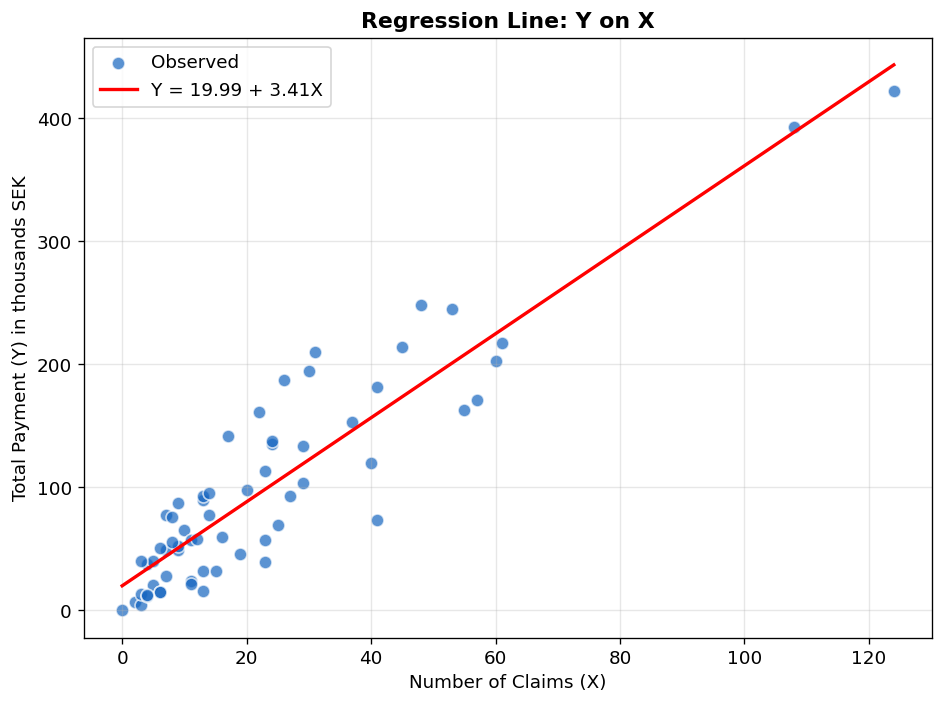

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X, Y, color='#1565C0', alpha=0.7, edgecolors='white', s=60, label='Observed')

x_pred = np.linspace(X.min(), X.max(), 100)
y_pred = b0 + b1 * x_pred
ax.plot(x_pred, y_pred, color='red', linewidth=2, label=f'Y = {b0:.2f} + {b1:.2f}X')

ax.set_title('Regression Line: Y on X', fontweight='bold')
ax.set_xlabel('Number of Claims (X)')
ax.set_ylabel('Total Payment (Y) in thousands SEK')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Predictions

In [12]:
print(f'{"X (Claims)":>12} | {"Predicted Y (000 SEK)":>22}')
print(f'{"-"*12} | {"-"*22}')
for x_val in [10, 25, 50, 75, 100]:
    y_pred_val = b0 + b1 * x_val
    print(f'{x_val:>12} | {y_pred_val:>22.2f}')

  X (Claims) |  Predicted Y (000 SEK)
------------ | ----------------------
          10 |                  54.13
          25 |                 105.34
          50 |                 190.69
          75 |                 276.03
         100 |                 361.38


---

## 3. Conclusion

This analysis looked at the relationship between the number of insurance claims (X) and total payment (Y) across 63 geographical zones in Sweden.

Both X and Y are positively skewed, with most zones having low values and a few zones having very high values. The scatter plot showed a clear positive linear pattern. The boxplots found 2 outliers in each variable, coming from the same two zones. These were kept in the analysis as they are genuine extreme values.

All three correlation methods (Pearson r = 0.9129, Spearman rho = 0.8649, Kendall tau = 0.7020) confirmed a strong positive relationship, all significant at the 0.05 level.

The regression equation Y = 19.9945 + 3.4138X explains 83.33% of the variation in total payment (R-squared = 0.8333). Both the intercept and slope are statistically significant. Each additional claim increases total payment by about 3.41 thousand SEK.

In summary, there is strong evidence of a significant positive linear relationship between claims and total payment in the Swedish auto insurance data.